# Practical 4: Dimensionality Reduction — PCA vs. Autoencoders
## Deep Learning Lab | BTech Semester 4

### Objective
Compare traditional linear dimensionality reduction (PCA) with neural dimensionality reduction (Autoencoders).



###   1: Install & Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.decomposition import PCA
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
print('Libraries loaded!')

Libraries loaded!


##  2: Load and Prepare MNIST
MNIST: 70,000 handwritten digit images, 28x28 pixels, 10 classes (0-9).
We reduce each image from 784 dimensions down to just 2 for 2D visualization.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 784), Test: (10000, 784)


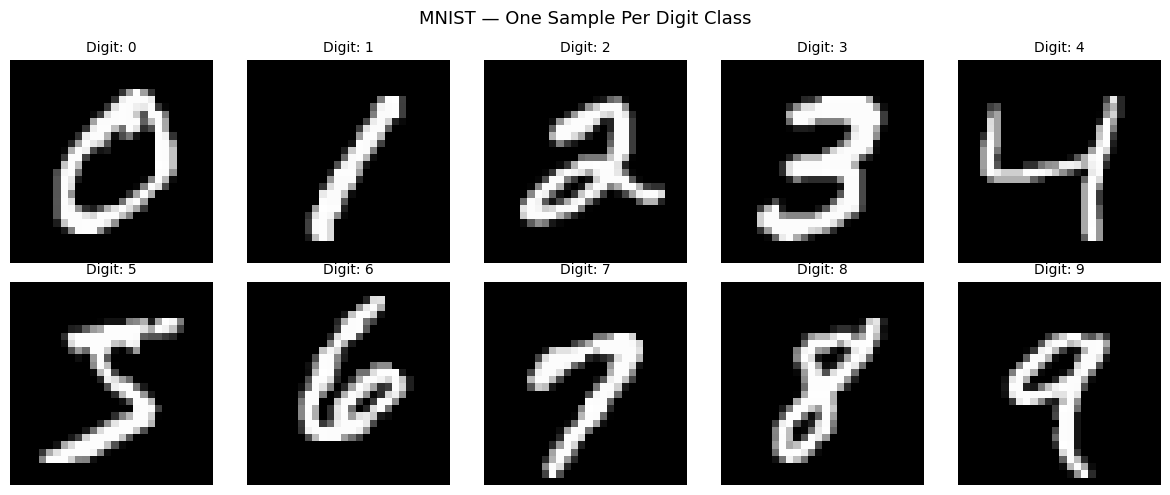

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Flatten and normalize pixels to [0, 1]
X_train_flat = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test_flat  = X_test.reshape(-1, 784).astype('float32')  / 255.0

print(f'Train: {X_train_flat.shape}, Test: {X_test_flat.shape}')

# Use a subset for faster visualization
N = 10000
X_sub = X_train_flat[:N]
y_sub = y_train[:N]

# Visualize sample digits — one per class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digit, ax in enumerate(axes.flatten()):
    idx = np.where(y_train == digit)[0][0]
    ax.imshow(X_train[idx], cmap='gray')
    ax.set_title(f'Digit: {digit}', fontsize=10)
    ax.axis('off')
plt.suptitle('MNIST — One Sample Per Digit Class', fontsize=13)
plt.tight_layout()
plt.show()

##  3: PCA — Principal Component Analysis

- Principal Component Analysis (PCA) is an unsupervised dimensionality reduction technique that transforms high-dimensional data into a lower-dimensional form while retaining most of the variance.
- It identifies new uncorrelated variables, called principal components, which are linear combinations of the original features.
- PCA minimizes information loss by maximizing variance.
- PCA finds the directions (principal components) of maximum variance in the data.
It is a LINEAR method — can only capture linear relationships between features.

Steps:
1. Center the data (subtract mean)
2. Compute covariance matrix
3. Compute eigenvectors (principal components) and eigenvalues
4. Project data onto top-K eigenvectors

Reducing 784 dimensions to 2 necessarily loses information!

In [3]:
# Fit PCA and reduce to 2 dimensions for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sub)  # Shape: (N, 2)

print(f'Original shape: {X_sub.shape}')
print(f'PCA reduced shape: {X_pca.shape}')
print(f'Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.2f}%')
print(f'Variance explained by PC2: {pca.explained_variance_ratio_[1]*100:.2f}%')
print(f'Total variance explained: {sum(pca.explained_variance_ratio_)*100:.2f}%')
print(f'Information lost by using only 2 components: {(1-sum(pca.explained_variance_ratio_))*100:.1f}%')

Original shape: (10000, 784)
PCA reduced shape: (10000, 2)
Variance explained by PC1: 10.20%
Variance explained by PC2: 7.22%
Total variance explained: 17.42%
Information lost by using only 2 components: 82.6%


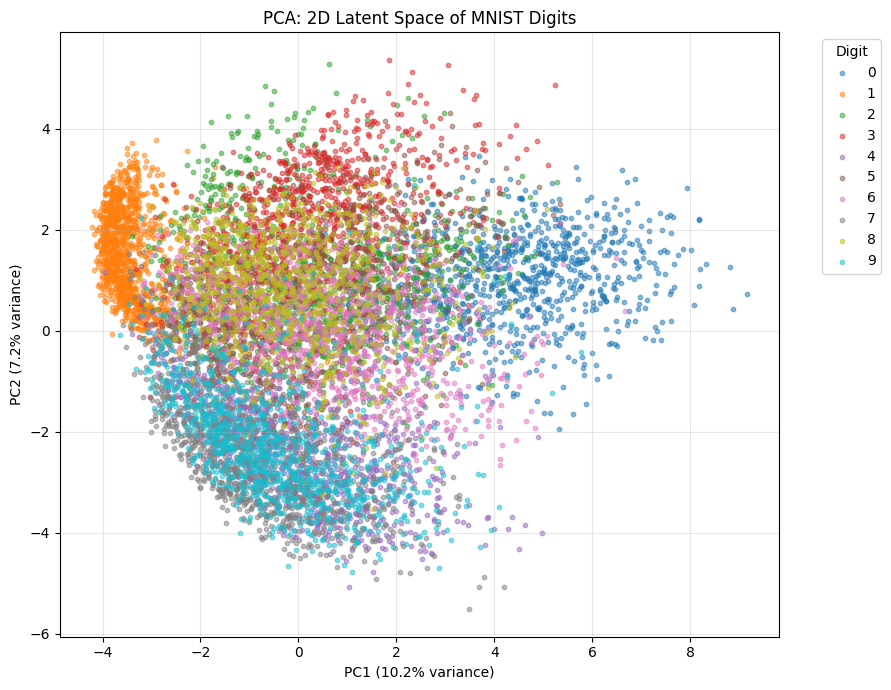

In [4]:
# Visualize PCA 2D latent space — color-coded by digit
colors = cm.tab10(np.linspace(0, 1, 10))
plt.figure(figsize=(9, 7))
for digit in range(10):
    mask = y_sub == digit
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=[colors[digit]], label=str(digit), alpha=0.5, s=10)
plt.legend(title='Digit', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('PCA: 2D Latent Space of MNIST Digits', fontsize=12)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##  4: Build the Autoencoder

- An autoencoder is an unsupervised neural network that learns to compress input data into a lower-dimensional representation (encoding) and then reconstructs the output to match the original input as closely as possible.
- It consists of an encoder, a bottleneck (latent space), and a decoder, primarily used for dimensionality reduction, denoising, and feature extraction

An Autoencoder is a neural network trained to:
- **Encode**: compress input (784 dims) to a small bottleneck (2 dims)
- **Decode**: reconstruct the original input from the bottleneck

Architecture:
```
Input(784) -> Dense(256) -> Dense(64) -> Bottleneck(2) -> Dense(64) -> Dense(256) -> Output(784)
```

The bottleneck forces the network to learn a compact, meaningful representation.
Unlike PCA, autoencoders can capture NON-LINEAR relationships between features.

In [5]:
LATENT_DIM = 2  # Same bottleneck size as PCA for fair comparison

# --- ENCODER: compresses 784 -> 2 ---
encoder_input = keras.Input(shape=(784,), name='encoder_input')
x = layers.Dense(256, activation='relu', name='enc_1')(encoder_input)
x = layers.Dense(64,  activation='relu', name='enc_2')(x)
latent = layers.Dense(LATENT_DIM, activation='linear', name='bottleneck')(x)
encoder = keras.Model(encoder_input, latent, name='Encoder')

# --- DECODER: reconstructs 2 -> 784 ---
decoder_input = keras.Input(shape=(LATENT_DIM,), name='decoder_input')
x = layers.Dense(64,  activation='relu', name='dec_1')(decoder_input)
x = layers.Dense(256, activation='relu', name='dec_2')(x)
output = layers.Dense(784, activation='sigmoid', name='decoder_output')(x)  # Sigmoid for [0,1] pixels
decoder = keras.Model(decoder_input, output, name='Decoder')

# --- FULL AUTOENCODER ---
ae_input = keras.Input(shape=(784,))
ae_output = decoder(encoder(ae_input))
autoencoder = keras.Model(ae_input, ae_output, name='Autoencoder')

# MSE loss: measures pixel-by-pixel reconstruction error
autoencoder.compile(optimizer='adam', loss='mse')
print('Autoencoder built!')
autoencoder.summary()

Autoencoder built!


Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder (Functional)            │ (None, 2)              │       217,538 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder (Functional)            │ (None, 784)            │       218,320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 435,858 (1.66 MB)

 Trainable params: 435,858 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

##  5: Train the Autoencoder
Key insight: Input = Target = X (unsupervised learning — no labels needed!)

Epoch 1/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0917 - val_loss: 0.0706
Epoch 2/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0655 - val_loss: 0.0623
Epoch 3/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0597 - val_loss: 0.0590
Epoch 4/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0570 - val_loss: 0.0566
Epoch 5/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0548 - val_loss: 0.0547
Epoch 6/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0529 - val_loss: 0.0525
Epoch 7/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0509 - val_loss: 0.0509
Epoch 8/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0496 - val_loss: 0.0497
Epoch 9/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0485 - val_loss: 0.0488
Epoch 10/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0476 - val_loss: 0.0481
Epoch 11/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0468 - val_loss: 0.0475
Epoch 12/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0

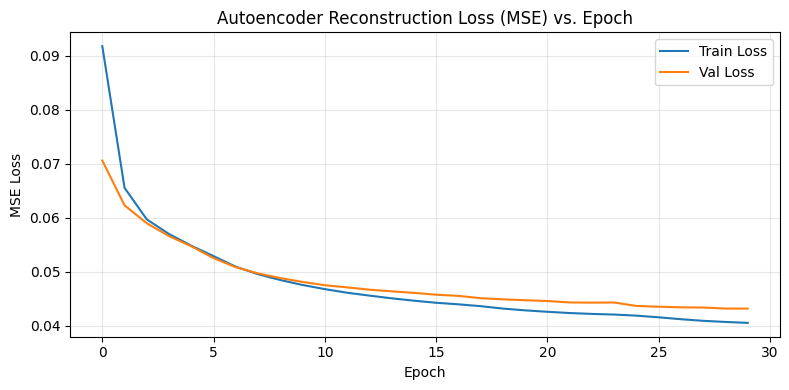

In [6]:
# Train: the autoencoder learns to minimize reconstruction error
history = autoencoder.fit(
    X_sub, X_sub,       # Input AND target are both X — self-supervised
    epochs=30,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Autoencoder Reconstruction Loss (MSE) vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##  6: Autoencoder Latent Space

- An autoencoder latent space is a low-dimensional bottleneck layer that compresses input data, capturing essential features while filtering noise.
- It acts as an internal representation, mapping input data into a compressed, meaningful structure where similar items often form distinct clusters.
- This bottleneck forces the network to learn efficient, salient, and meaningful representations, crucial for data compression and dimensionality reduction.

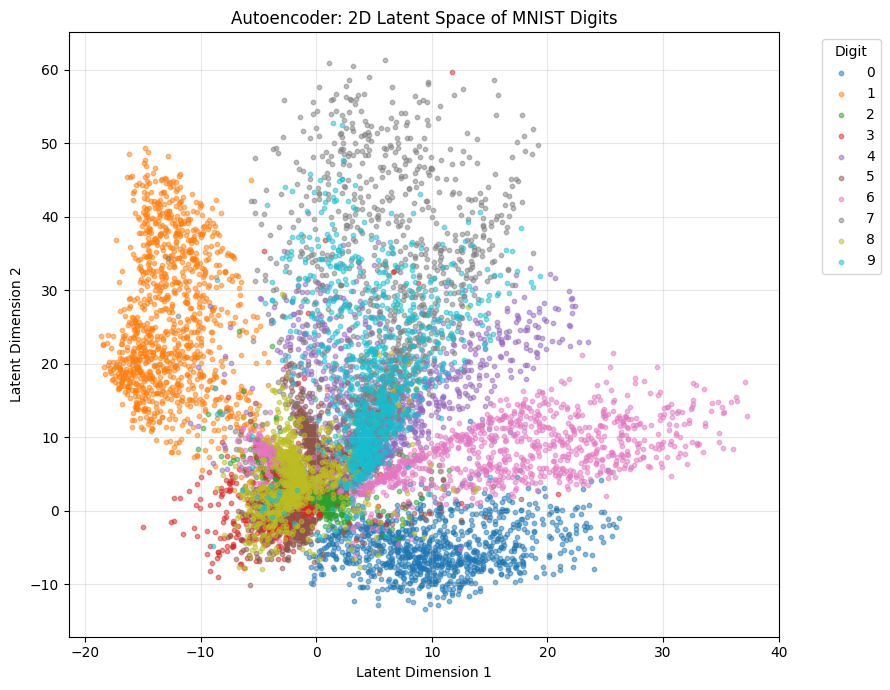

In [7]:
# Encode the data — get 2D latent representations
X_ae = encoder.predict(X_sub, verbose=0)

plt.figure(figsize=(9, 7))
for digit in range(10):
    mask = y_sub == digit
    plt.scatter(X_ae[mask, 0], X_ae[mask, 1],
                c=[colors[digit]], label=str(digit), alpha=0.5, s=10)
plt.legend(title='Digit', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Autoencoder: 2D Latent Space of MNIST Digits', fontsize=12)
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##  7: Side-by-Side Comparison of Latent Spaces
- Comparing latent spaces involves analyzing how different generative models (like GANs, VAEs, or Diffusion models) compress data into lower-dimensional representations.
- These spaces are compared by measuring their structure, dimensionality, smoothness, and how well they organize data semantically.

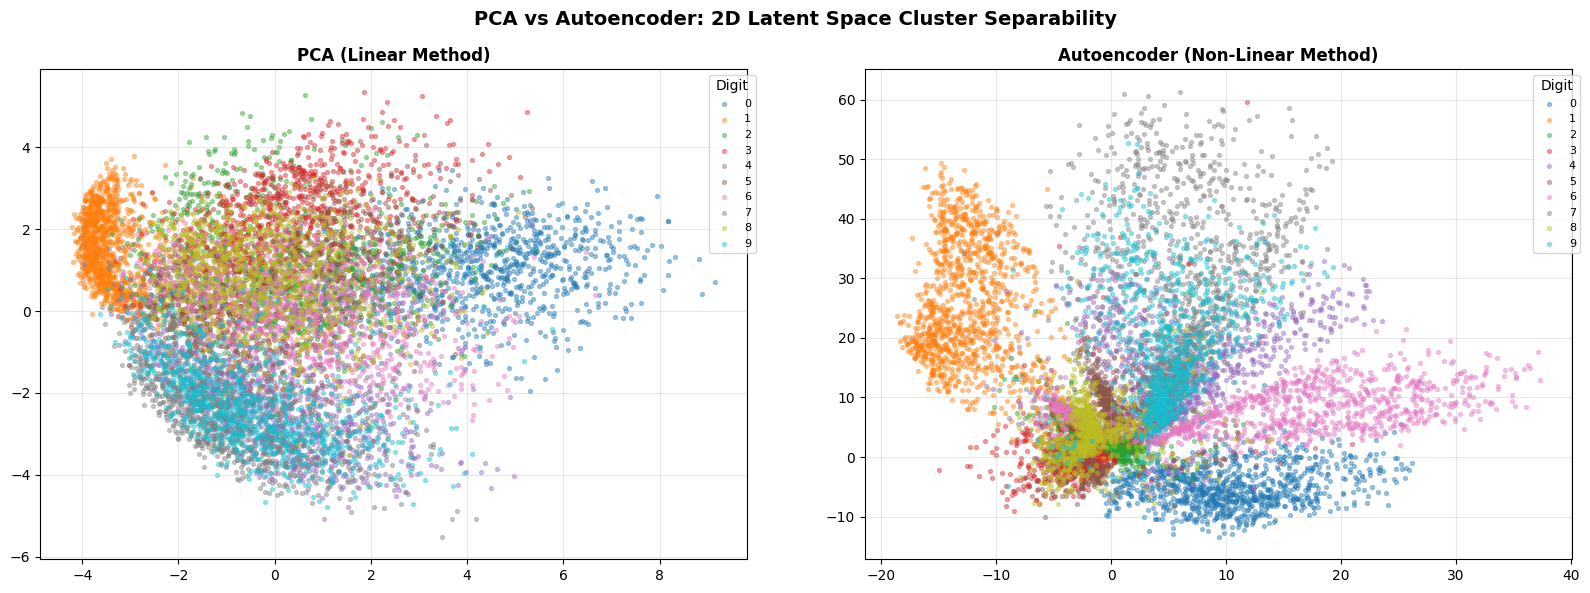

The Autoencoder generally shows better-separated digit clusters
because it can learn non-linear manifolds, unlike PCA which is restricted to linear projections.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for digit in range(10):
    mask = y_sub == digit
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=[colors[digit]], label=str(digit), alpha=0.4, s=8)
    axes[1].scatter(X_ae[mask, 0], X_ae[mask, 1], c=[colors[digit]], label=str(digit), alpha=0.4, s=8)

for ax, title in zip(axes, ['PCA (Linear Method)', 'Autoencoder (Non-Linear Method)']):
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(title='Digit', bbox_to_anchor=(1.02, 1), fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('PCA vs Autoencoder: 2D Latent Space Cluster Separability', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('The Autoencoder generally shows better-separated digit clusters')
print('because it can learn non-linear manifolds, unlike PCA which is restricted to linear projections.')

##  8: Reconstruction Quality Comparison
- Reconstruction quality comparison involves evaluating how accurately a generated model, image, or signal represents the original, with, and efficiency being key tradeoffs.
- In fields like 3D scanning, medical imaging (CT), and computer vision, different methods prioritize either high-fidelity detail or rapid processing speed.

In [ ]:
n_show = 8
sample = X_test_flat[:n_show]
ae_recon = autoencoder.predict(sample, verbose=0)

# PCA reconstruction via inverse_transform
pca_recon = np.clip(pca.inverse_transform(pca.transform(sample)), 0, 1)

fig, axes = plt.subplots(3, n_show, figsize=(16, 6))
row_labels = ['Original', 'PCA Recon.', 'AE Recon.']
for i in range(n_show):
    axes[0, i].imshow(sample[i].reshape(28, 28), cmap='gray')
    axes[1, i].imshow(pca_recon[i].reshape(28, 28), cmap='gray')
    axes[2, i].imshow(ae_recon[i].reshape(28, 28), cmap='gray')
    for r in range(3):
        axes[r, i].axis('off')
for r, lbl in enumerate(row_labels):
    axes[r, 0].set_ylabel(lbl, fontsize=11)
plt.suptitle('Reconstruction Quality: Original vs PCA vs Autoencoder', fontsize=13)
plt.tight_layout()
plt.show()

---
## Summary

| Aspect | PCA | Autoencoder |
|--------|-----|-------------|
| Method type | Linear | Non-linear |
| Training | Eigen-decomposition (fast) | Backprop (slower) |
| Reconstruction | Blurry | Sharper |
| Cluster separation | Partial overlap | Better separation |
| Interpretability | High (explained variance) | Low (black box) |

---
